# 01 — Dublin Airbnb: EDA & Cleaning

**Project:** Dublin Airbnb Market Analysis & Price Prediction
**Author:** Rodion Omelich · [GitHub](https://github.com/RodionOm)
**Dataset:** [Inside Airbnb — Dublin, 16 Sep 2025](https://insideairbnb.com/dublin/)

## Goals of this notebook
1. Load raw listings, calendar, reviews
2. Profile data quality (missingness, types, outliers)
3. Apply standardized cleaning via `src/cleaning.py`
4. Persist a clean `listings_clean.parquet` for downstream notebooks

> **Decision log** — every non-trivial choice is justified inline.


In [1]:
# Setup
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_listings, load_calendar, save_processed
from src.cleaning import clean_listings, filter_price_iqr

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)


## 1. Load raw data

In [2]:
raw = load_listings()
print(f'Shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head(2)

Shape: 6,945 rows × 79 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,...,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44077,https://www.airbnb.com/rooms/44077,20250916040708,2025-09-16,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,https://www.airbnb.com/users/show/193005,Teresa,2010-08-06,"Dublin, Ireland","I am a friendly outgoing Irishwoman ,who love...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/2167f...,https://a0.muscache.com/im/pictures/user/2167f...,Churchtown,2.0,2.0,"['email', 'phone']",t,t,"Churchtown, Ireland",Dn Laoghaire-Rathdown,NaN,...,NaN,t,6,9,9,9,2025-09-16,394,37,5,9,42,222,19092.0,2011-03-20,2025-09-13,4.82,4.86,4.77,4.93,4.93,4.68,4.83,NaN,f,2,0,2,0,2.23
1,85156,https://www.airbnb.com/rooms/85156,20250916040708,2025-09-16,previous scrape,Cosy Comfortable Irish Cottage 1 Double Bed,Our Cottage is a charming light filled cottage...,"I love Dundrum and its surrounding areas ,<br ...",https://a0.muscache.com/pictures/1749253/9ed2a...,193005,https://www.airbnb.com/users/show/193005,Teresa,2010-08-06,"Dublin, Ireland","I am a friendly outgoing Irishwoman ,who love...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/2167f...,https://a0.muscache.com/im/pictures/user/2167f...,Churchtown,2.0,2.0,"['email', 'phone']",t,t,"Churchtown, Ireland",Dn Laoghaire-Rathdown,NaN,...,NaN,t,7,7,7,7,2025-09-16,357,41,5,7,41,246,NaN,2011-05-24,2025-09-14,4.81,4.84,4.75,4.91,4.89,4.64,4.77,NaN,f,2,0,2,0,2.05


In [3]:
# Missingness profile — which columns are unusable?
missing = (raw.isna().mean() * 100).round(1).sort_values(ascending=False)
missing[missing > 0].head(20)

license                         100.0
calendar_updated                100.0
neighbourhood_group_cleansed    100.0
neighbourhood                    64.3
neighborhood_overview            64.3
host_about                       59.8
host_location                    25.9
bathrooms                        24.6
beds                             24.5
estimated_revenue_l365d          24.5
price                            24.5
host_neighbourhood               20.3
last_review                      15.0
review_scores_cleanliness        15.0
reviews_per_month                15.0
review_scores_location           15.0
first_review                     15.0
review_scores_rating             15.0
review_scores_accuracy           15.0
review_scores_checkin            15.0
dtype: float64

### Observations on missingness
- `price` missing in ~25% → these listings cannot be used as supervised samples
  for price prediction. **Drop only at modeling stage**, keep for descriptive stats.
- `review_scores_*` and `reviews_per_month` ~15% missing → listings without reviews.
  For `reviews_per_month` we impute 0 (it has semantic meaning), for scores we keep NaN.
- `bedrooms`/`beds`/`bathrooms` ~9–25% → impute with median (mostly 1 in studios).
- `license` >50% missing → drop, not useful.


## 2. Apply standardized cleaning

In [4]:
df = clean_listings(raw)
print(f'After cleaning: {df.shape}')
print(f'Remaining columns dtype summary:')
df.dtypes.value_counts()

After cleaning: (6945, 80)
Remaining columns dtype summary:


float64           28
str               22
int64             20
datetime64[us]     5
boolean            5
Name: count, dtype: int64

In [5]:
# Sanity check: types after cleaning
df[['price','host_is_superhost','host_response_rate','host_since',
    'instant_bookable','neighbourhood_norm']].head()

,price,host_is_superhost,host_response_rate,host_since,instant_bookable,neighbourhood_norm
0,86.0,True,1.0,2010-08-06,False,Churchtown
1,NaN,True,1.0,2010-08-06,False,Churchtown
2,48.0,False,0.7,2011-07-01,False,Dublin
3,101.0,False,1.0,2011-07-04,False,Dublin
4,NaN,False,1.0,2011-10-04,False,Dublin


## 3. Price distribution (raw vs IQR-filtered)

In [6]:
price = df['price'].dropna()
print(f'N (non-null price): {len(price):,}')
print(price.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(1))

N (non-null price): 5,244
count     5244.0
mean       204.5
std        401.0
min         16.0
1%          36.4
5%          55.0
25%         89.0
50%        137.0
75%        232.0
95%        489.0
99%       1000.0
max      19140.0
Name: price, dtype: float64


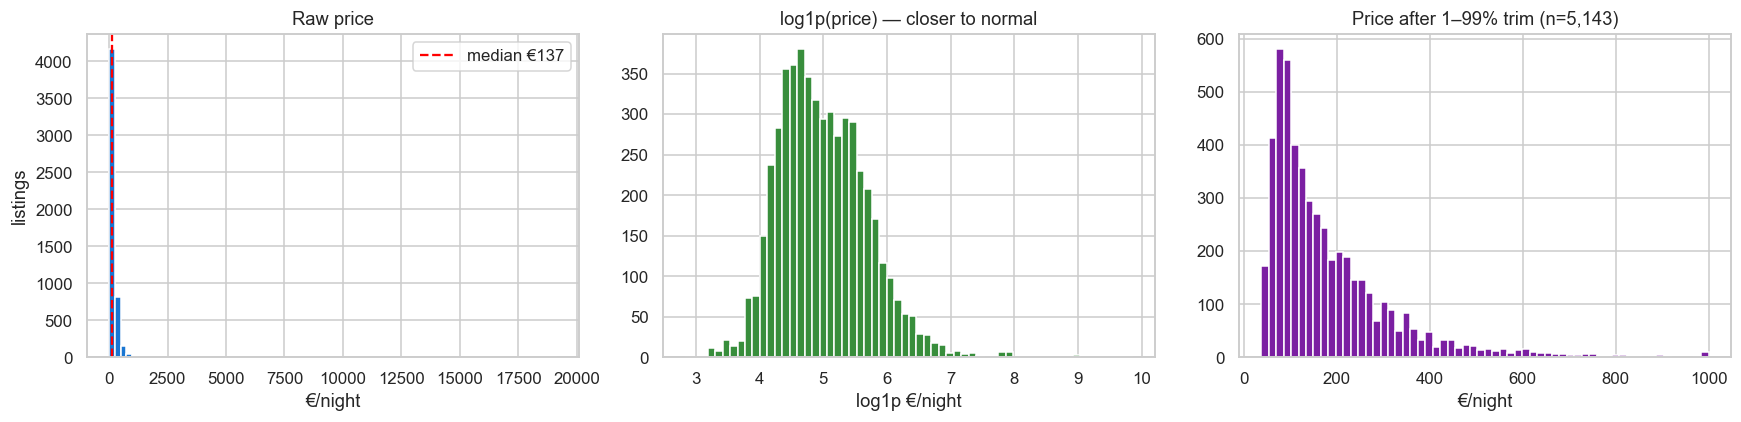

In [7]:
# Visual: raw vs log-transform
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(price, bins=80, color='#1976D2', edgecolor='white')
axes[0].set(title='Raw price', xlabel='€/night', ylabel='listings')
axes[0].axvline(price.median(), color='red', ls='--', label=f'median €{price.median():.0f}')
axes[0].legend()

axes[1].hist(np.log1p(price), bins=60, color='#388E3C', edgecolor='white')
axes[1].set(title='log1p(price) — closer to normal', xlabel='log1p €/night')

# IQR-filtered
df_iqr = filter_price_iqr(df)
axes[2].hist(df_iqr['price'], bins=60, color='#7B1FA2', edgecolor='white')
axes[2].set(title=f'Price after 1–99% trim (n={len(df_iqr):,})', xlabel='€/night')

plt.tight_layout()
plt.savefig('../reports/figures/01_price_distributions.png', dpi=140, bbox_inches='tight')
plt.show()

**Why log-transform?** Price is right-skewed (long tail of €500+ listings).
RMSE on raw price is dominated by these few; log1p stabilizes variance and
makes residuals more interpretable as *percentage errors*. The ML notebook
predicts `log1p(price)` and exponentiates back.

## 4. Room type & property structure

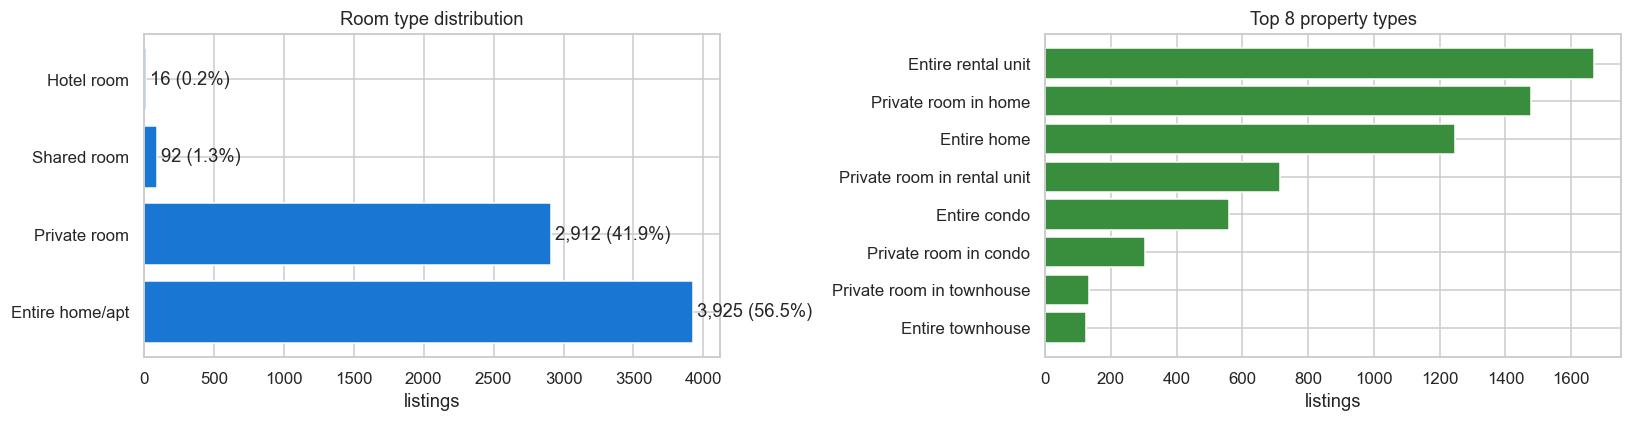

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

room_counts = df['room_type'].value_counts()
axes[0].barh(room_counts.index, room_counts.values, color='#1976D2')
for i, v in enumerate(room_counts.values):
    axes[0].text(v+30, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center')
axes[0].set(title='Room type distribution', xlabel='listings')

top_props = df['property_type'].value_counts().head(8)
axes[1].barh(top_props.index[::-1], top_props.values[::-1], color='#388E3C')
axes[1].set(title='Top 8 property types', xlabel='listings')

plt.tight_layout()
plt.savefig('../reports/figures/02_room_property_types.png', dpi=140, bbox_inches='tight')
plt.show()

## 5. Geography — coarse neighbourhoods

In [9]:
# Note: Inside Airbnb's 'neighbourhood_cleansed' for Dublin has only 4 regions.
# For modeling we use lat/lon → distance features (see 02_features.ipynb).
nbh = df.groupby('neighbourhood_cleansed').agg(
    n_listings=('id','count'),
    median_price=('price','median'),
    mean_price=('price','mean'),
    median_rating=('review_scores_rating','median'),
).round(1).sort_values('n_listings', ascending=False)
nbh

,n_listings,median_price,mean_price,median_rating
neighbourhood_cleansed,,,,
Dublin City,4815,150.0,215.1,4.8
Fingal,853,108.0,201.7,4.9
Dn Laoghaire-Rathdown,792,137.0,198.2,4.9
South Dublin,485,91.5,131.1,4.9


## 6. Host portfolio — commercial vs individual

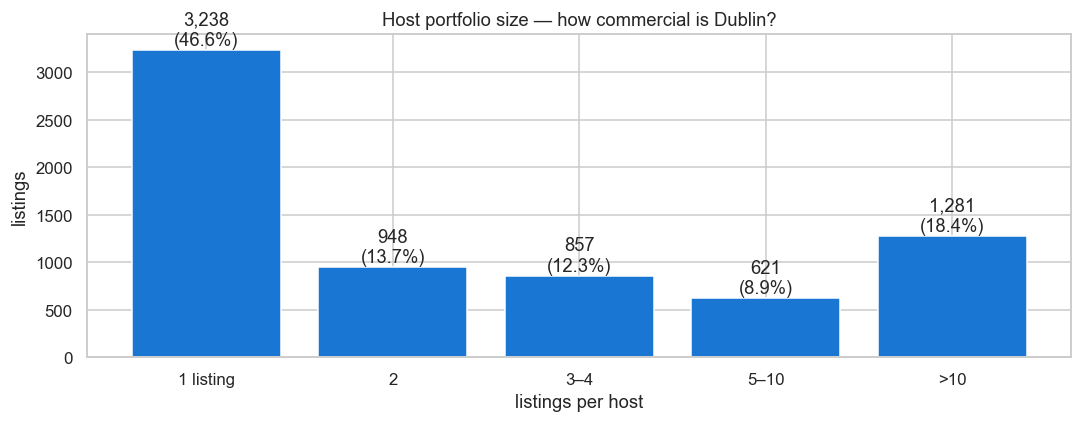


>>> 27.4% of listings belong to hosts with 5+ properties


In [10]:
host_size = df['calculated_host_listings_count']
buckets = pd.cut(host_size, bins=[0,1,2,4,10,1000],
                 labels=['1 listing','2','3–4','5–10','>10'])
host_buckets = buckets.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(host_buckets.index.astype(str), host_buckets.values, color='#1976D2')
for i, v in enumerate(host_buckets.values):
    ax.text(i, v+50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
ax.set(title='Host portfolio size — how commercial is Dublin?',
       xlabel='listings per host', ylabel='listings')
plt.tight_layout()
plt.savefig('../reports/figures/03_host_portfolio.png', dpi=140, bbox_inches='tight')
plt.show()

pct_commercial = (host_size >= 5).mean() * 100
print(f'\n>>> {pct_commercial:.1f}% of listings belong to hosts with 5+ properties')

## 7. Persist cleaned data

In [11]:
save_processed(df, 'listings_clean', fmt='parquet')
print('✅ Saved: data/processed/listings_clean.parquet')

✅ Saved: data/processed/listings_clean.parquet


---
## Key takeaways
- **6.9k listings** across Dublin region; clean subset of ~5.2k for price modeling
- **Price is heavily right-skewed** → log-transform for modeling
- **Dublin City dominates** (70% of listings); Fingal/DLR/South Dublin minor
- **Commercial hosts** (5+ listings) control a meaningful share of supply
- Next: **02_features.ipynb** builds engineered features for the ML pipeline
